In [1]:

import numpy as np
import sys, os
sys.path.append(os.path.abspath(".."))

import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from matplotlib import patches
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel
from regions import CircleSkyRegion, CirclePixelRegion
from scipy.interpolate import interp1d
import healpy as hp
# from reproject import reproject_from_healpix
import json

import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
# from astropy.wcs import utils as asutils
# from astropy.visualization.wcsaxes.frame import EllipticalFrame

from scipy.optimize import curve_fit
from skimage.filters import difference_of_gaussians, gaussian
# from skimage.io import imread, imshow
# from skimage.feature import peak_local_max
# from skimage import color, exposure, transform
from skimage.feature import blob_dog, blob_log, blob_doh
from matplotlib.backends.backend_pdf import PdfPages
from scipy.ndimage import gaussian_filter

from helpers import *
%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload
milagrotextcolor, milagro = setupMilagroColormap(-3, 15, 2, 256)
milagrotextcolor2, milagro2 = setupMilagroColormap(0.2, 1, 2, 256)

In [2]:
import yaml

with open("/lustre/hawcz01/scratch/userspace/rbabu/astroimage/AstroImageDetection/datasets/3HWC.yaml", "r") as f:
   catalog = yaml.safe_load(f)

names = []
ra = []
dec = []
ext = []

for src in catalog:
    names.append(src.get("name"))
    ra.append(src.get("RA"))
    dec.append(src.get("Dec"))
    ext.append(0.01)   # constant extension for all sources

# Build DataFrame in your desired format
sources3hwc = pd.DataFrame({
    "Name": names,
    "ra": ra,
    "dec": dec,
    "ext": ext,
})

print(sources3hwc)

              Name        ra      dec   ext
0   3HWC J0534+220   83.6279  22.0243  0.01
1   3HWC J0540+228   85.1660  22.8719  0.01
2   3HWC J0543+231   85.7812  23.1150  0.01
3   3HWC J0617+224   94.3945  22.4676  0.01
4   3HWC J0621+382   95.3174  38.2059  0.01
..             ...       ...      ...   ...
60  3HWC J2022+431  305.5220  43.1580  0.01
61  3HWC J2023+324  305.8150  32.4429  0.01
62  3HWC J2031+415  307.9250  41.5107  0.01
63  3HWC J2043+443  310.8880  44.3007  0.01
64  3HWC J2227+610  336.9620  61.0482  0.01

[65 rows x 4 columns]


ROI center 40.5, 0
ROI center in Galactic Coordintes = 40.5, 0
Loading Galactic Map
Fits File loaded
Degrees per pixel: 0.005555555555555556 
Shape of Map in pixel number: 1440 X 1080
Degrees per pixel: 0.005555555555555556 
Peak intensity pixel location: (576, 534)
Peak intensity sky location: <SkyCoord (Galactic): (l, b) in deg
    (40.52777978, -0.7944508)>
Peak intensity value: 36.33236574937659
None
Plotting contours [7, 9, 12, 13, 14, 15]
Peak intensity pixel location: (576, 534)
Peak intensity sky location: <SkyCoord (Galactic): (l, b) in deg
    (40.52777978, -0.7944508)>
Peak intensity value: 36.33236574937659


(286.32637083823437, 6.731402016860154)

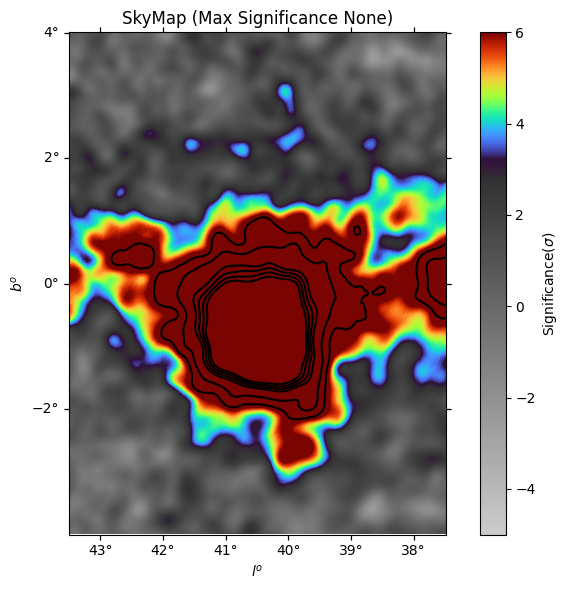

In [19]:
# Load the Simulation FITS file
filename = '/Users/rishi/Documents/Analysis/data/aerie-apps_bin1-9__allsky_1024_i2.5_r0.0_p1.0.fits'
outdir = os.getcwd()+ '/galactic_plane_plots/'

ra_center = 40.5
dec_center = 0
coord_sys = 'G'
xlength=3
ylength=4

# ra_center = 83.5
# dec_center = 22
# coord_sys = 'C'
# xlength=5
# ylength=5

save_pdf = False
if save_pdf:
    pdf = PdfPages(os.path.join(outdir, f'run-{ra_center}-{dec_center}-plots.pdf'))
print(f"ROI center {ra_center}, {dec_center}")

 

array, _, wcs, xnum, ynum, pixel_size = load_hawc_data(filename, ra_center, dec_center, xlength, ylength, coord_sys)
print(f'Shape of Map in pixel number: {ynum} X {xnum}')
print(f'Degrees per pixel: {pixel_size} ')
max_signif=find_peak(array, wcs)
print(max_signif)
fig, ax=make_plots(array, wcs, pixel_size, coordsys='G', threshold=3, vmin=-5, vmax=6, contour=True, title=f'SkyMap (Max Significance {max_signif})', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
if save_pdf:
    pdf.savefig(fig)  
find_peak(array, wcs)
gal_to_cel(ra_center, dec_center)


Plotting contours [7, 9, 12, 13, 14, 15]


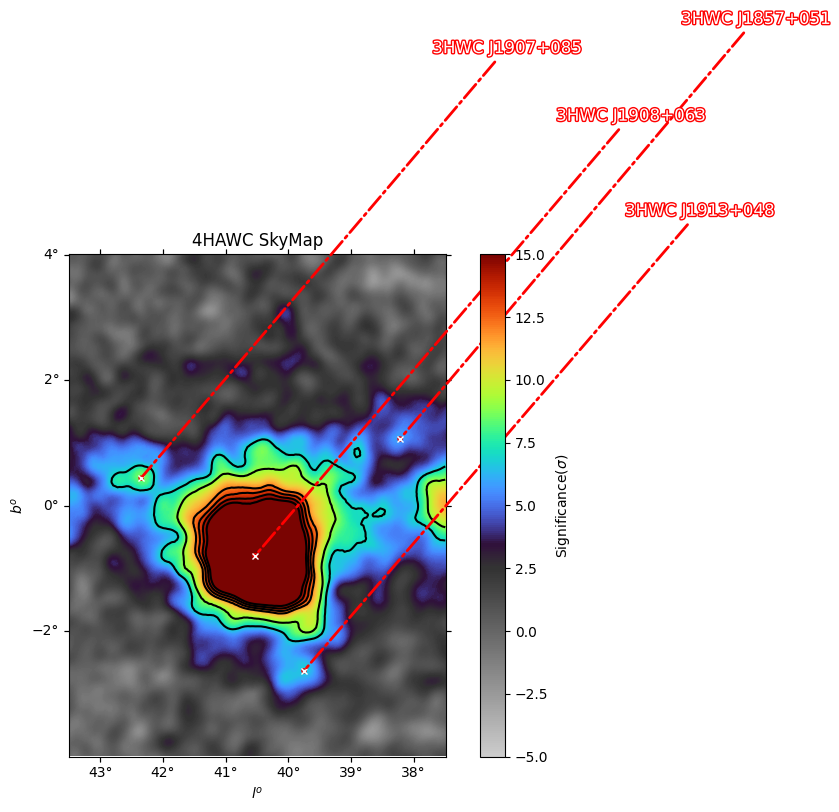

In [20]:
fig,ax=make_plots(array, wcs, pixel_size, coordsys='G', threshold=3, vmin=-5, vmax=15, contour=True, title='4HAWC SkyMap',hotspots=sources3hwc, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
if save_pdf:
    pdf.savefig(fig)  

In [21]:
# Stop if there are no hotspots greater than 5 sigma
if np.max(array) < 5:
    print(f'Algorithm wont proceed. Significance Map has no data greater than 4$\sigma$)')
    fig, ax = plt.subplots(figsize=(8.5, 11))  # Create a blank canvas (8.5x11 inches for letter size)
    ax.axis('off')  # Turn off axes
    text = f"Algorithm wont proceed. Significance Map has no data greater than 4$\sigma$)"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
    plt.show()
    if save_pdf:
        pdf.savefig(fig)  
    exit
else:
    print(f'Algorithm will proceed. Significance Map has data greater than 4$\sigma$)')

Algorithm will proceed. Significance Map has data greater than 4$\sigma$)


In [22]:
print("Min significance in Loaded Map=",np.min(array))
print("Max significance in Loaded Map=",np.max(array))
if np.min(array) < -6:
    print("Image softly floored to -5 sigma")
    array = soft_floor(array, floor_min=-6, scale=1.0)

Min significance in Loaded Map= -2.6179335252839633
Max significance in Loaded Map= 36.33236574937659


Significant deviation from Gaussian on positive side at:34,  4.10099
Signal (mean excess): 9.47721
Noise (background RMS): 1.71764
SNR: 5.52
Peak SNR: 21.15
2 sigma deviation from Gaussian fit on positive side 3.43528
3 sigma deviation from Gaussian fit on positive side 3.43528
Mask deviation value: 4.10099, Sigma of Gaussian fit: 1.71764
Signal-to-noise ratio (SNR) metric based on deviation from Gaussian fit: 2.3875723853083013
Signal-to-noise ratio (SNR) metric based blah: 5.5175721789864225


(4.100993099594984, 3.4352827372523267, 5.1529241058784905)

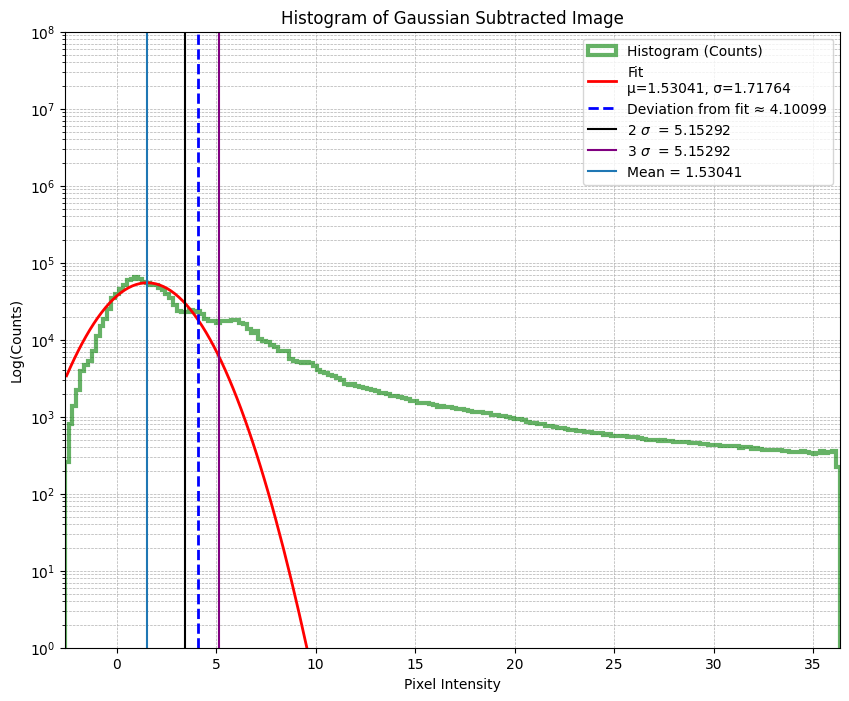

In [23]:
analyze_histogram(array, plot=True)

In [24]:
# # Calculate the 1D histogram of the image
# pixels = array.flatten()
# binlen = int(len(pixels)/1000)
# print(f"Length of bins={binlen}")
# counts, bin_edges = np.histogram(pixels, bins=binlen, range=(-4, np.max(pixels)))
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 

# def gaussian_fit(x, amplitude, mean, stddev):
#     return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2))

# x_exp = np.linspace(-5, 5, binlen)
# y_exp = gaussian_fit(x_exp, counts.max(), 0, 1)

# initial_guess = [counts.max(), bin_centers[np.argmax(counts)], np.std(pixels)]
# popt, _ = curve_fit(gaussian_fit, bin_centers, counts, p0=initial_guess)
# # x_fit = np.linspace(bin_centers[0]-2, bin_centers[-1], 500)
# x_fit = np.linspace(-6, np.max(pixels), binlen)
# y_fit = gaussian_fit(x_fit, *popt)

# plt.figure(figsize=(8, 8))

# log_counts = np.where(counts > 0, counts, 1) 
# plt.hist(pixels, bins=binlen, range=(np.min(pixels), np.max(pixels)), color='fuchsia', edgecolor='green', alpha=0.6, label='Histogram (Counts)', histtype='step', linewidth=3)
# plt.plot(x_exp, y_exp, 'red', linewidth=2, label=f'Expectation\nμ=0, σ=0.01')
# plt.plot(x_fit, y_fit, 'blue', linewidth=2, label=f'Fit\nμ={popt[1]:.5f}, σ={popt[2]:.5f}')
# plt.yscale('log')
# plt.ylim(0.5, 1e6)
# plt.xlim(-6, 6)
# plt.xlabel('Pixel Intensity')
# plt.ylabel('Log(Counts)')
# plt.title('Histogram of Image')
# plt.legend()
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.show()
# if save_pdf:
#     pdf.savefig(fig)  
# plt.close()

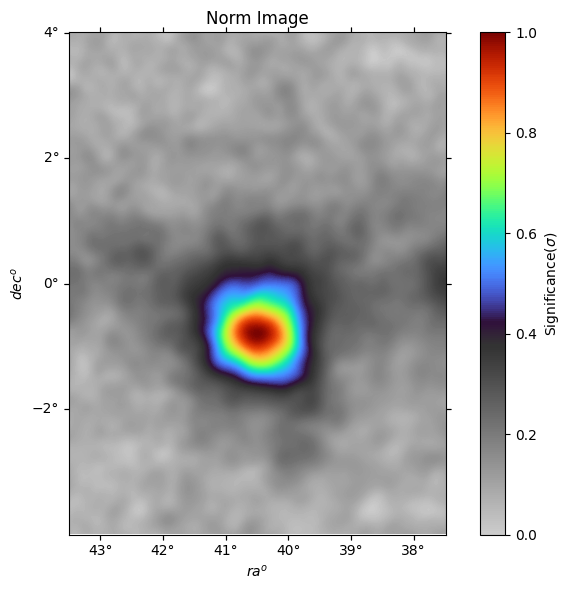

In [25]:
#Normalize the image between 0 and 1 for analysis

image = array
norm_image = (image-np.min(image))/(np.max(image)-np.min(image))
fig,ax=make_plots(norm_image, wcs, pixel_size, coordsys='C', threshold=0.4, vmin=0, vmax=1, contour=False, title='Norm Image', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6))
if save_pdf:
    pdf.savefig(fig) 

Pixel Size=0.0028
Number of pixels corresponding to 0.40 smear radius = 144.00


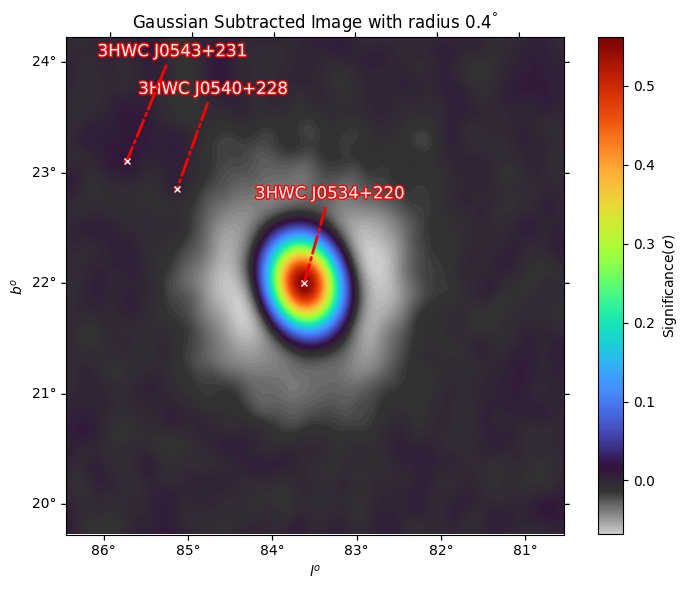

In [246]:
# Find the Difference of Gaussian (DoG) Image
smear_radius=0.4 #PSF of the dec band
print(f"Pixel Size={pixel_size:.4f}")
print(f"Number of pixels corresponding to {smear_radius:.2f} smear radius = {smear_radius/pixel_size:.2f}")
dog_image = difference_of_gaussians(norm_image, 1, smear_radius/pixel_size)
fig,ax=make_plots(dog_image, wcs, pixel_size, coordsys='G', threshold=0.005, hotspots=sources3hwc,vmin=np.min(dog_image), vmax=np.max(dog_image), title=f'Gaussian Subtracted Image with radius {smear_radius}$^\degree$', cmap='ult')
if save_pdf:
    pdf.savefig(fig) 

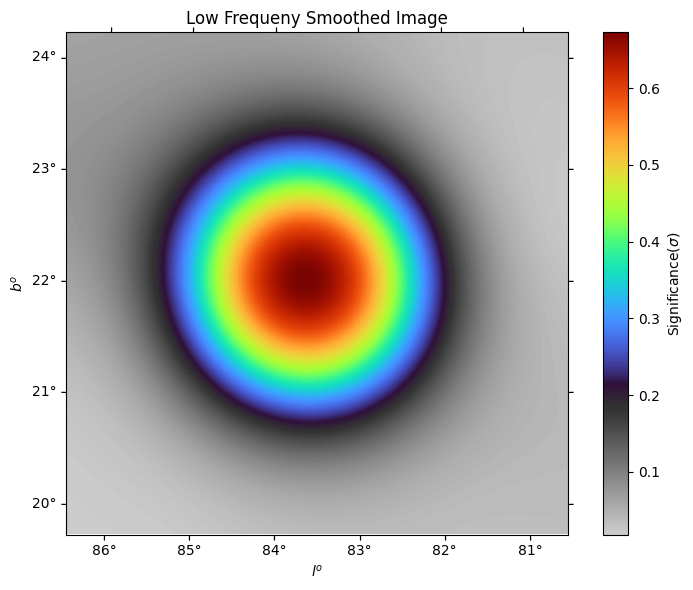

In [247]:
norm_dog_image = (dog_image-np.min(dog_image))/(np.max(dog_image)-np.min(dog_image))
lowfreq_image=norm_image-norm_dog_image
norm_lowfreq_image = (lowfreq_image-np.min(lowfreq_image))/(np.max(lowfreq_image)-np.min(lowfreq_image))
norm_lowfreq_image = gaussian(norm_lowfreq_image, sigma=0.5/pixel_size)
fig,ax=make_plots(norm_lowfreq_image, wcs, pixel_size, vmin=np.min(norm_lowfreq_image), vmax=np.max(norm_lowfreq_image), hotspots=None,threshold=0.2,coordsys='G',title=f'Low Frequeny Smoothed Image', cmap='ult', labels=['4haawc'])
if save_pdf:
    pdf.savefig(fig) 

Significant deviation from Gaussian on positive side at:27,  0.01813
2 sigma deviation from Gaussian fit on positive side 0.01053
3 sigma deviation from Gaussian fit on positive side 0.01053


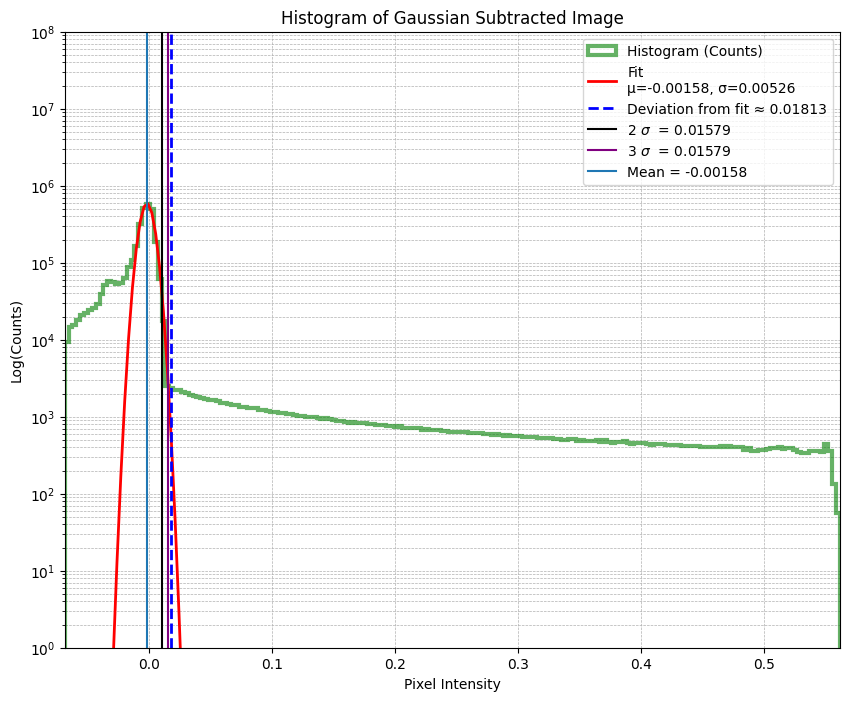

In [248]:
mask_deviation_value, deviation_2sig, deviation_3sig= analyze_histogram(dog_image, plot=True)

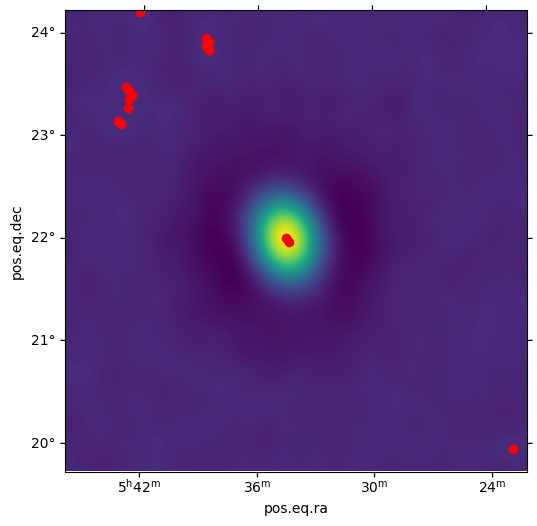

In [252]:
from skimage.feature import peak_local_max
coords = peak_local_max(dog_image, threshold_abs=deviation_2sig)
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1, projection=wcs)
plt.imshow(norm_dog_image)
plt.scatter(coords[:,1], coords[:,0], c='r')

In [217]:
# # Count pixels above the threshold
# num_pixels_above = np.sum(norm_dog_image > deviation_location)
# print(f"Number of pixels above {deviation_location}: {num_pixels_above}")

# # Optional: fraction of total image
# fraction_above = num_pixels_above / norm_dog_image.size
# print(f"Fraction of image above threshold: {fraction_above:.4f}")

# plt.imshow(norm_dog_image, cmap='gray')
# plt.scatter(*np.where(norm_dog_image > deviation_location)[::-1], c='r', s=10)
# plt.title(f"Pixels above {deviation_location}")
# plt.show()

In [255]:
# Find the blobs from the DoG image
#  mask_deviation_value, deviation_3sig
threshold_val = 0.005
ps_blobs = blob_dog(dog_image, min_sigma=0.1/pixel_size, max_sigma=smear_radius/pixel_size, threshold=threshold_val, exclude_border=50, overlap=0.5)
print("Number of point source blobs=",len(ps_blobs))
ext_blobs = blob_dog(dog_image, min_sigma=smear_radius/pixel_size, max_sigma=0.5/pixel_size, threshold=threshold_val, exclude_border=50, overlap=0.5)
print("Number of ext source blobs=",len(ext_blobs))

ps_blobs = ps_blobs[ps_blobs[:, 2] < smear_radius/pixel_size]
ext_blobs = ext_blobs[ext_blobs[:, 2] > smear_radius/pixel_size]
print("Number of point source blobs=",len(ps_blobs))
print("Number of ext source blobs=",len(ext_blobs))

Number of point source blobs= 7
Number of ext source blobs= 2
Number of point source blobs= 7
Number of ext source blobs= 0


In [259]:
deviation_2sig

0.010527688069751451

Number of point source blobs= 1
Number of ext source blobs= 0


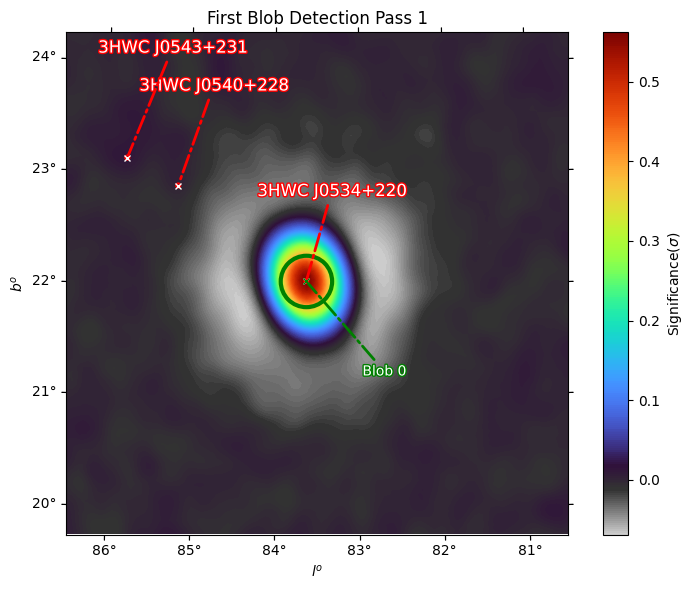

In [262]:
# DoG Image Intensity Filtering
deviation2 = deviation_2sig
intensity_min=deviation2

ps_filtered_blobs, ps_filtered_coords, ps_filtered_radius = blob_filter_intensity(ps_blobs, dog_image, intensity_min, wcs, pixel_size)
print("Number of point source blobs=",len(ps_filtered_blobs))

ext_filtered_blobs, ext_filtered_coords, ext_filtered_radius = blob_filter_intensity(ext_blobs, dog_image, intensity_min, wcs, pixel_size)
print("Number of ext source blobs=",len(ext_filtered_blobs))
blobs_dict = {
    'psblobs': ps_filtered_blobs,
    'extblobs': ext_filtered_blobs,
}
fig,ax=make_plots(dog_image, wcs, pixel_size, coordsys='G', threshold=0.005, hotspots=sources3hwc,blobs=blobs_dict,vmin=np.min(dog_image), vmax=np.max(dog_image), title=f'First Blob Detection Pass 1', cmap='ult', labels=['4haawc'])
if save_pdf:
    pdf.savefig(fig) 

No of ps =  1
No of ext =  0


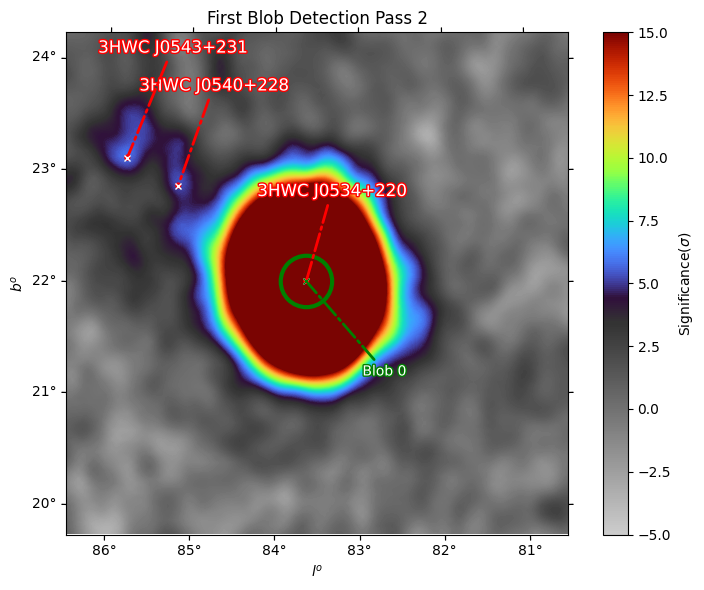

In [263]:
# Input Significance Image Intensity Filtering
ps_filtered_blobs2, ps_filtered_coords2, ps_filtered_radius2 = blob_filter_intensity(ps_filtered_blobs, array,5 , wcs, pixel_size)
ext_filtered_blobs3, ext_filtered_coords3, ext_filtered_radius3 = blob_filter_intensity(ext_filtered_blobs, array, 5, wcs, pixel_size)
print("No of ps = ", len(ps_filtered_blobs2))
print("No of ext = ", len(ext_filtered_blobs3))
blobs_dict = {
    'psblobs': ps_filtered_blobs2,
    'extblobs': ext_filtered_blobs3,
}
fig,ax=make_plots(array, wcs, pixel_size,coordsys='G', hotspots=sources3hwc,blobs=blobs_dict, title=f'First Blob Detection Pass 2', cmap='ult')

if save_pdf:
    pdf.savefig(fig)

Number of ext source blobs= 1
Number of ext source blobs= 1


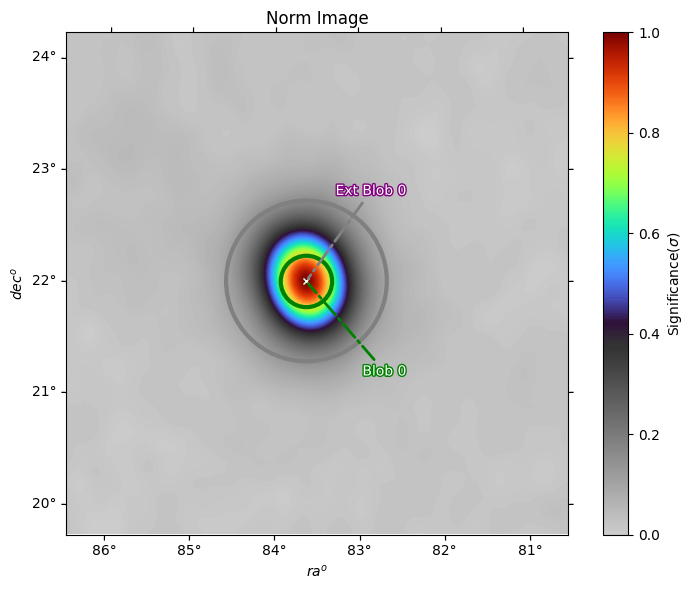

In [264]:
# Find the blobs from the Gaussian Smeared Image
ext_blobs4 = blob_dog(norm_lowfreq_image,min_sigma=0.5/pixel_size, max_sigma=0.8/pixel_size, threshold=0.01, exclude_border=30)#, sigma_ratio=4)
print("Number of ext source blobs=",len(ext_blobs4))
# Filter the Gaussian Blobs from above
ext_filtered_blobs4, ext_filtered_coords4, ext_filtered_radius4 = blob_filter_intensity(ext_blobs4, array, 3, wcs, pixel_size)
print("Number of ext source blobs=",len(ext_filtered_blobs4))
blobs_dict = {
    'psblobs': ps_filtered_blobs2,
    'extblobs': ext_filtered_blobs4,
}

fig,ax=make_plots(norm_image, wcs, pixel_size, coordsys='C', threshold=0.4, vmin=0, vmax=1, contour=False, title='Norm Image', blobs=blobs_dict, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6),labels=['4haawc'])

if save_pdf:
    pdf.savefig(fig)

In [265]:
all_coords = ps_filtered_coords2  + ext_filtered_coords3 + ext_filtered_coords4
all_radii = ps_filtered_radius2  + ext_filtered_radius3 + ext_filtered_radius4

# filtered_df = filter_overlapping_sources(all_coords, all_radii, radius_to_sigma,  max_distance_deg=1)
filtered_df = no_filter(all_coords, all_radii, radius_to_sigma,  max_distance_deg=1)

# t_coords = ps_filtered_coords2 
# t_radii = ps_filtered_radius2 

# Filter ext group 4
# valid_idx = remove_ext_sources_with_radius_overlap(
#     t_coords, t_radii,
#     ext_filtered_coords4, ext_filtered_radius4
# )

# # Apply filtering
# ext_filtered_coords4 = [ext_filtered_coords4[i] for i in valid_idx]
# ext_filtered_radius4 = [ext_filtered_radius4[i] for i in valid_idx]
# ext_filtered_blobs4  = [ext_filtered_blobs4[i]  for i in valid_idx]

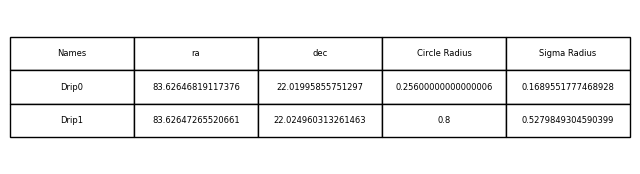

In [266]:
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off') 

try:
    table = ax.table(cellText=filtered_df.values,
                        colLabels=filtered_df.columns,
                        cellLoc='center',
                        loc='center')

    table.scale(1, 2)
except:
    text = f"DRIPS Compilation of Result for Crab Simulation Run {file}. No Source Found"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
plt.show()
plt.close(fig)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


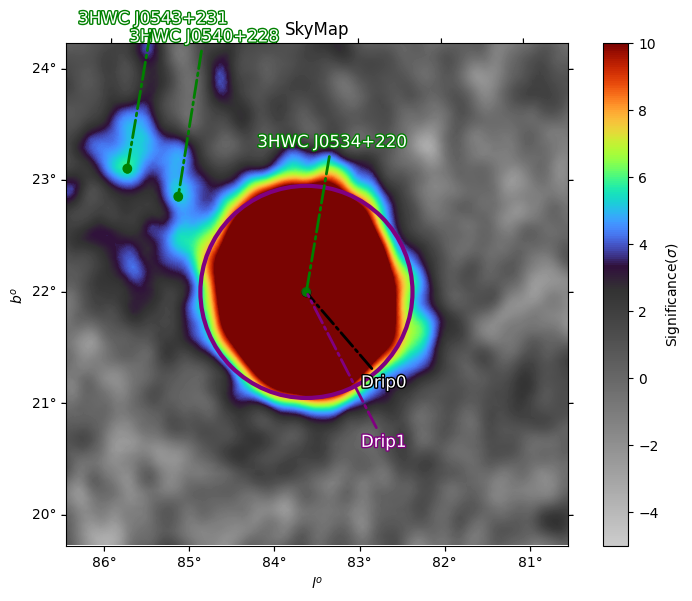

In [267]:
# Plot the Final Seeds
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
seed_final = pd.DataFrame({
    "Name": filtered_df['Names'], 
    "ra": filtered_df['ra'],
    "dec":  filtered_df['dec'], 
    "ext": filtered_df['Sigma Radius'],
    })
name = ['ic443 ps', 'halo ext']
ra = [94.42, 93.67]
dec = [22.35, 22.22]
ext = [0.01, 1.05]

fig,ax=make_plots(array, wcs, pixel_size,threshold=3, vmin=-5, vmax=10,  coordsys='G',hotspots=None, hotspots2=None, title=f'SkyMap', cmap='ult', labels=['4haawc', '1lhaaaso', '4fagl', 'sanr', 'pulsaar'])

for i in range(len(seed_final)):
    coord2 = SkyCoord(ra=filtered_df['ra'][i]*u.deg, dec=filtered_df['dec'][i]*u.deg)
    pixelcoord = astropy_utils.skycoord_to_pixel(coord2, wcs)
    r = filtered_df['Sigma Radius'][i] / pixel_size

    if i%2 == 0:
        if r > 80:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='purple')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, -90), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='purple', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="purple")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 2*r, color='purple', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='black')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, -90), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='black', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="black")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='black', linewidth=3, fill=False)
    else:
        if r > 80:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='purple')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, -150), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='purple', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="purple")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 2*r, color='purple', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='black')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, -150), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='black', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="black")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='black', linewidth=3, fill=False)
    ax.add_patch(c)

ra = sources3hwc['ra']
dec = sources3hwc['dec']
ext = sources3hwc['ext']
name= sources3hwc['Name']
for i in range(len(sources3hwc)):
    coord2 = SkyCoord(ra=ra[i]*u.deg, dec=dec[i]*u.deg)
    pixelcoord = astropy_utils.skycoord_to_pixel(coord2, wcs)
    r = ext[i] / pixel_size
    if i%2 == 0:
        if r > 100:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 90), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), r, color='green', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 150), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='green', linewidth=3, fill=False)
    else:
        if r > 100:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 120), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), r, color='green', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 160), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='green', linewidth=3, fill=False)
    ax.add_patch(c)


if save_pdf:
    pdf.savefig(fig)
    pdf.close()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


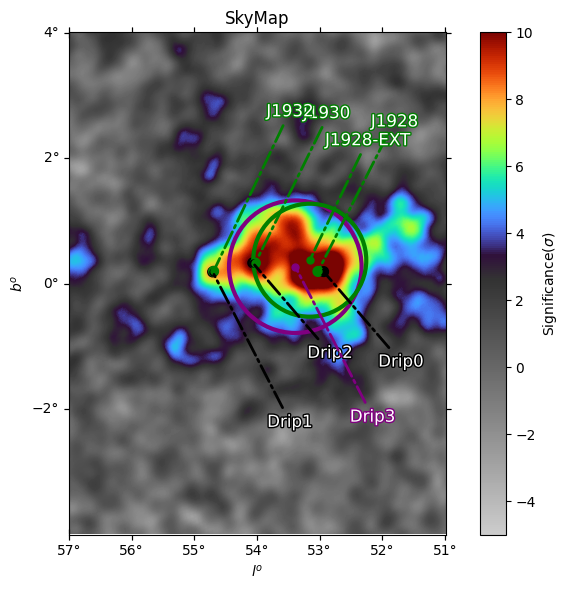

In [203]:
# Plot the Final Seeds
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
seed_final = pd.DataFrame({
    "Name": filtered_df['Names'], 
    "ra": filtered_df['ra'],
    "dec":  filtered_df['dec'], 
    "ext": filtered_df['Sigma Radius'],
    })


fig,ax=make_plots(array, wcs, pixel_size,threshold=3, vmin=-5, vmax=10,  coordsys='G',hotspots=None, hotspots2=None, title=f'SkyMap', cmap='ult', labels=['4haawc', '1lhaaaso', '4fagl', 'sanr', 'pulsaar'])

for i in range(len(seed_final)):
    coord2 = SkyCoord(ra=filtered_df['ra'][i]*u.deg, dec=filtered_df['dec'][i]*u.deg)
    pixelcoord = astropy_utils.skycoord_to_pixel(coord2, wcs)
    r = filtered_df['Sigma Radius'][i] / pixel_size

    if i%2 == 0:
        if r > 80:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='purple')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, -90), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='purple', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="purple")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 2*r, color='purple', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='black')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, -90), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='black', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="black")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='black', linewidth=3, fill=False)
    else:
        if r > 80:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='purple')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, -150), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='purple', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="purple")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 2*r, color='purple', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='black')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, -150), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='black', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="black")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='black', linewidth=3, fill=False)
    ax.add_patch(c)
name = ['J1930 ', 'J1932', 'J1928', 'J1928-EXT']
ra = [292.53, 292.99, 292.15, 292.05]
dec = [18.84, 19.36, 17.90, 18.10]
ext = [0.01, 0.01, 0.01, 0.9]
for i in range(len(name)):
    coord2 = SkyCoord(ra=ra[i]*u.deg, dec=dec[i]*u.deg)
    pixelcoord = astropy_utils.skycoord_to_pixel(coord2, wcs)
    r = ext[i] / pixel_size
    if i%2 == 0:
        if r > 100:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 90), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), r, color='green', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 150), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='green', linewidth=3, fill=False)
    else:
        if r > 100:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 120), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), r, color='green', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 160), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='green', linewidth=3, fill=False)
    ax.add_patch(c)


if save_pdf:
    pdf.savefig(fig)
    pdf.close()

In [182]:
sources3hwc

,Name,ra,dec,ext
0,3HWC J0534+220,83.6279,22.0243,0.01
1,3HWC J0540+228,85.1660,22.8719,0.01
2,3HWC J0543+231,85.7812,23.1150,0.01
3,3HWC J0617+224,94.3945,22.4676,0.01
4,3HWC J0621+382,95.3174,38.2059,0.01
...,...,...,...,...
60,3HWC J2022+431,305.5220,43.1580,0.01
61,3HWC J2023+324,305.8150,32.4429,0.01
62,3HWC J2031+415,307.9250,41.5107,0.01
63,3HWC J2043+443,310.8880,44.3007,0.01


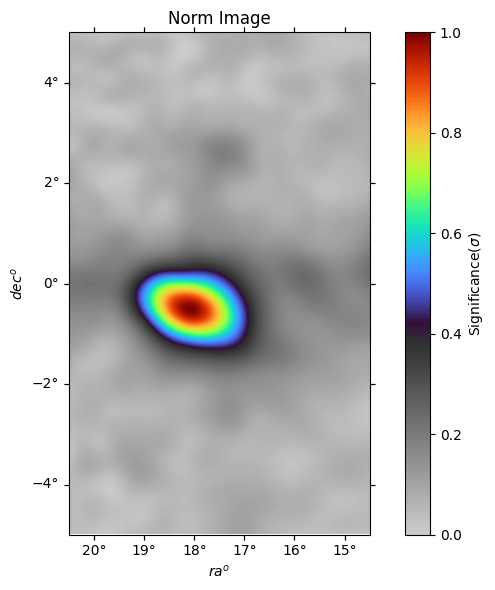

In [41]:
fig,ax=make_plots(norm_image, wcs, pixel_size, coordsys='C', threshold=0.4, vmin=0, vmax=1, contour=False, title='Norm Image', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6))

In [42]:
counterparts=get_simbad_counterparts(filtered_df, ra_center, dec_center, filename)

    Name   snr  lmxb  hmxb                                             pulsar  \
0  Drip0  None  None  None                                     [PSR B1823-13]   
1  Drip1  None  None  None                                   [PSR J1813-1246]   
2  Drip2  None  None  None  [PSR J1818-1502, PSR J1819-1458, PSR B1817-15....   

    sfr  
0  None  
1  None  
2  None  


Pixel Size=0.0056
Number of pixels corresponding to 0.20 smear radius = 36.00
Significant deviation from Gaussian on positive side at:97,  0.02591
Signal (mean excess): 0.04386
Noise (background RMS): 0.01320
SNR: 3.32
Peak SNR: 8.22
2 sigma deviation from Gaussian fit on positive side 0.02640
3 sigma deviation from Gaussian fit on positive side 0.02640
Mask deviation value: 0.02591, Sigma of Gaussian fit: 0.01320
Signal-to-noise ratio (SNR) metric based on deviation from Gaussian fit: 1.9629291317755022
Signal-to-noise ratio (SNR) metric based blah: 3.323476220138065
Number of point source blobs= 65
Number of ext source blobs= 3
Number of point source blob 1st filter= 9
Number of ext source blobs= 1
No of ps 2nd filter=  6
No of ext =  1
Pixel Size=0.0056
Number of pixels corresponding to 0.30 smear radius = 54.00
Significant deviation from Gaussian on positive side at:78,  0.03290
Signal (mean excess): 0.06939
Noise (background RMS): 0.01720
SNR: 4.04
Peak SNR: 11.68
2 sigma deviatio

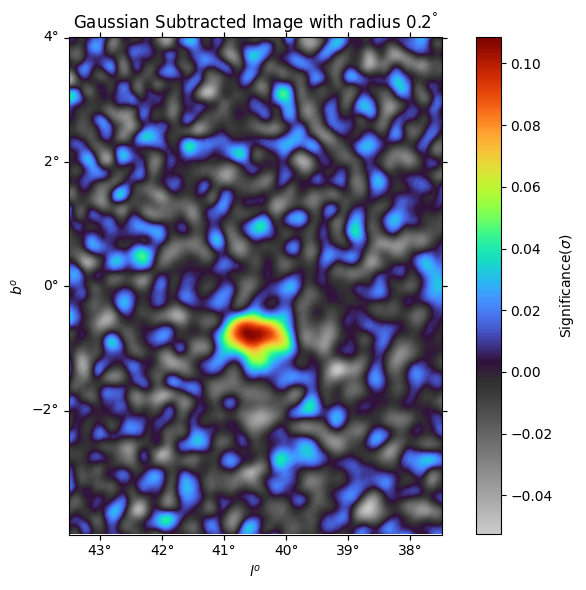

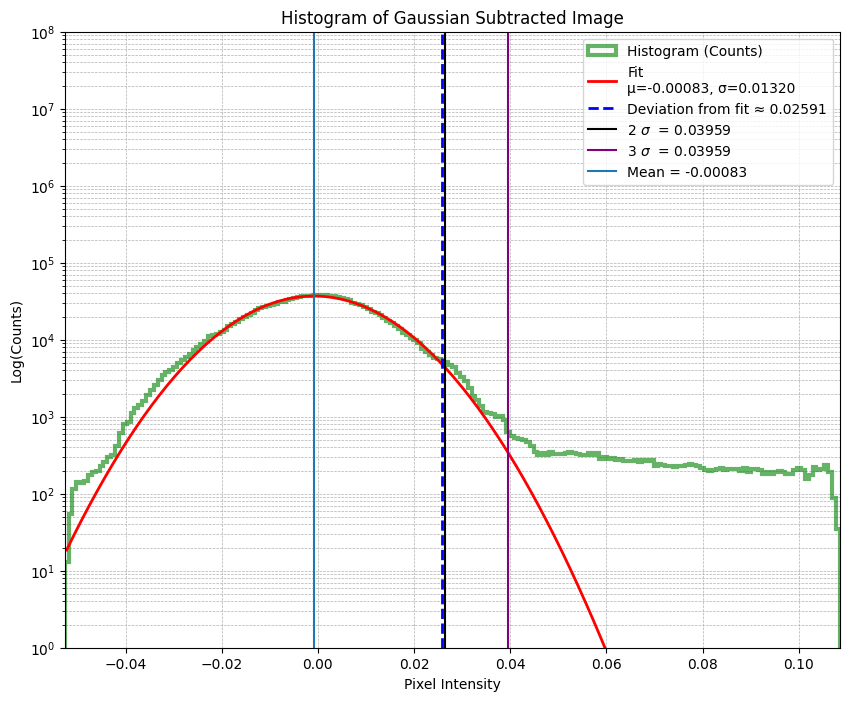

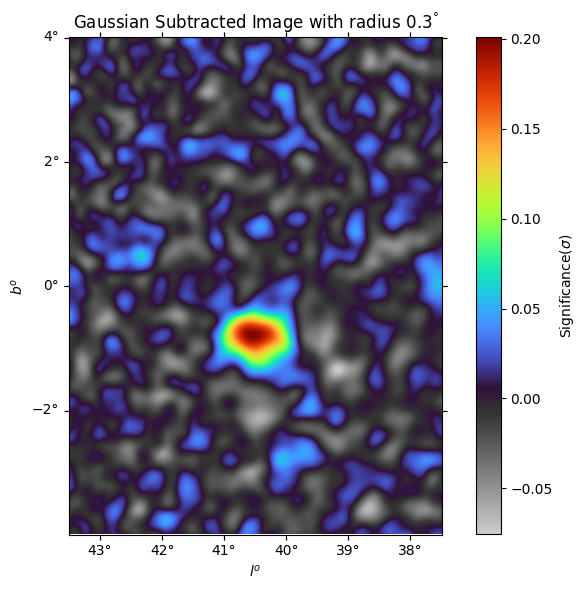

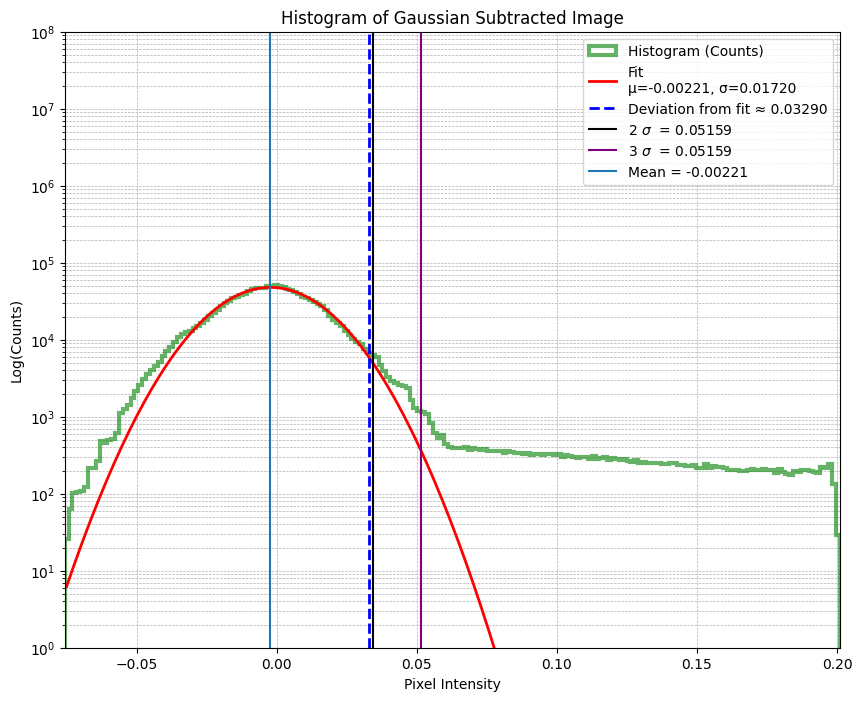

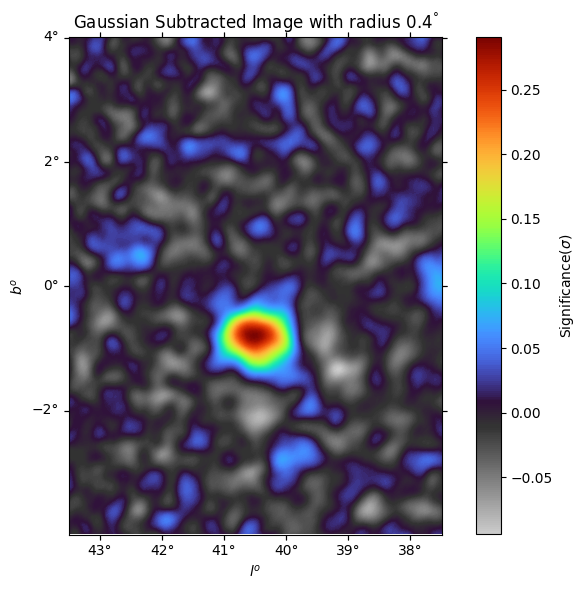

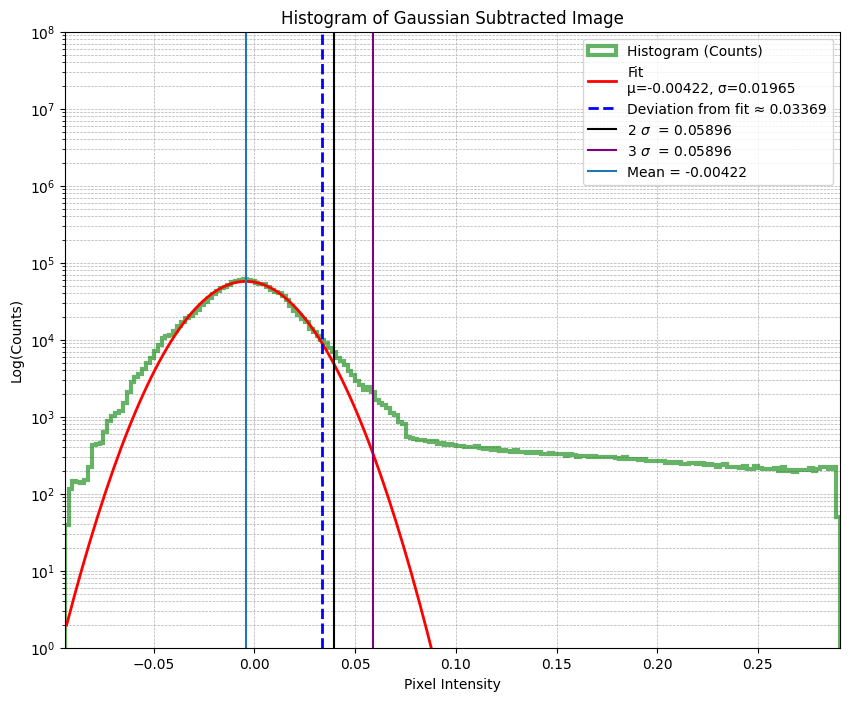

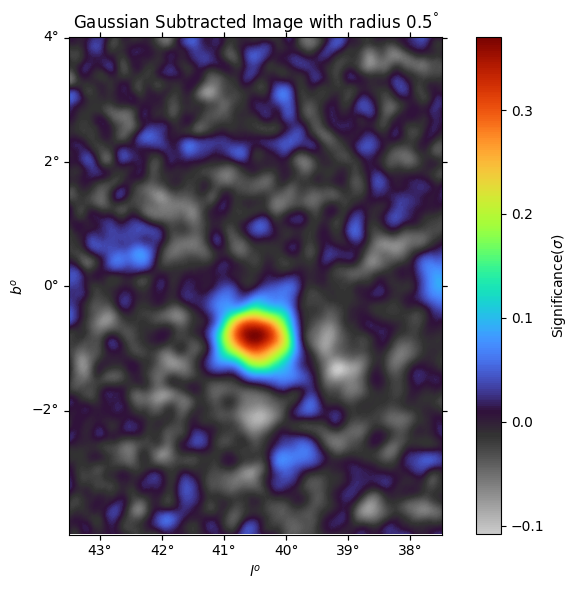

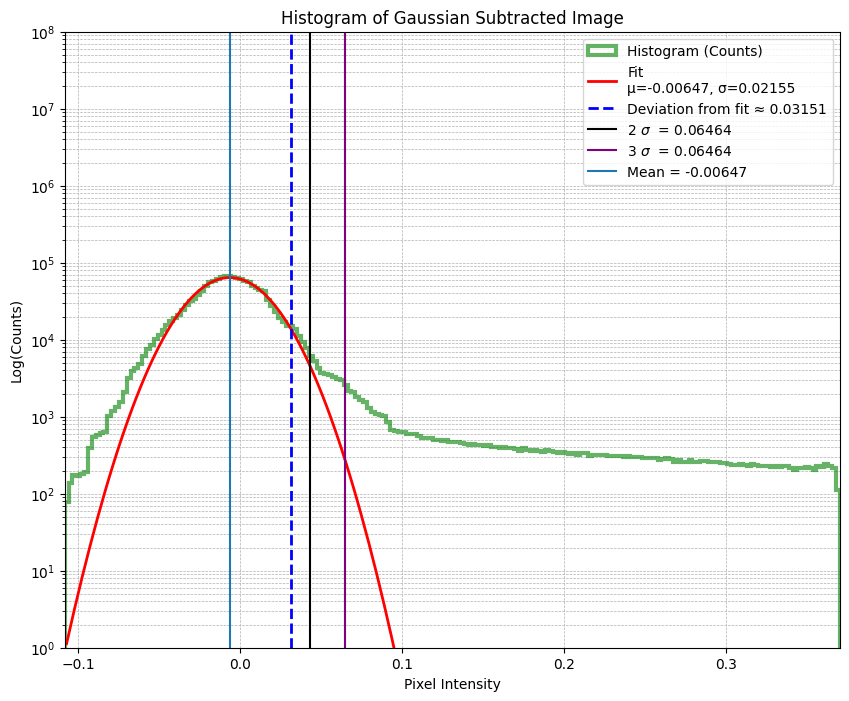

In [42]:
from scipy.spatial.distance import cdist

# Initialize lists to store all blobs from all iterations
all_ps_blobs = []
all_ext_blobs = []
all_pscoord_blobs = []
all_extcoord_blobs = []
all_psradius_blobs = []
all_extradius_blobs = []
for radius in [0.2, 0.3, 0.4, 0.5]:
# Find the Difference of Gaussian (DoG) Image
    smear_radius=radius #PSF of the dec band
    print(f"Pixel Size={pixel_size:.4f}")
    print(f"Number of pixels corresponding to {smear_radius:.2f} smear radius = {smear_radius/pixel_size:.2f}")
    dog_image = difference_of_gaussians(norm_image, 1, smear_radius/pixel_size)
    # smoothed = dog_image
    # smoothed = smoothed[::4, ::4]
    # x = np.arange(smoothed.shape[1])
    # y = np.arange(smoothed.shape[0])
    # X, Y = np.meshgrid(x, y)

    # coordinates = peak_local_max(smoothed, min_distance=5, threshold_rel=0.1)
    # peak_x = coordinates[:, 1]
    # peak_y = coordinates[:, 0]
    # peak_z = smoothed[peak_y, peak_x]


    # fig = plt.figure(figsize=(6, 5))#, dpi=80)
    # ax = fig.add_subplot(111, projection='3d')
    # surface = ax.plot_surface(X, Y, smoothed, cmap='plasma', edgecolor='none')
    # peaks_plot = ax.scatter(peak_x, peak_y, peak_z, c='black', s=50, label='Peaks')
    # ax.set_xlabel('X')
    # ax.set_ylabel('Y')
    # ax.set_zlabel('Intensity')
    # ax.set_title('3D Surface Histogram of Significance')
    # def update(frame):
    #     ax.view_init(elev=30, azim=frame)
    #     return fig,

    # ani = animation.FuncAnimation(fig, update, frames=np.arange(0, 360, 2), interval=50)
    # ani.save(f'gaussian_surface_rotation-{smear_radius}.gif', writer='pillow')
    fig,ax=make_plots(dog_image, wcs, pixel_size, coordsys='G', threshold=0.0000005,vmin=np.min(dog_image), vmax=np.max(dog_image), title=f'Gaussian Subtracted Image with radius {smear_radius}$^\degree$', cmap='ult')
    # if save_pdf:
    #     pdf.savefig(fig) 
    norm_dog_image = (dog_image-np.min(dog_image))/(np.max(dog_image)-np.min(dog_image))
    # fig,ax=make_plots(norm_dog_image, wcs, pixel_size, vmin=np.min(norm_dog_image), vmax=np.max(norm_dog_image), hotspots=None,threshold=0.2,coordsys='G',title=f'Low Frequeny Smoothed Image', cmap='ult', labels=['4haawc'])
    # if save_pdf:
    #     pdf.savefig(fig) 
    lowfreq_image=norm_image-norm_dog_image
    norm_lowfreq_image = (lowfreq_image-np.min(lowfreq_image))/(np.max(lowfreq_image)-np.min(lowfreq_image))
    norm_lowfreq_image = gaussian(norm_lowfreq_image, sigma=0.5/pixel_size)
    # fig,ax=make_plots(norm_lowfreq_image, wcs, pixel_size, vmin=np.min(norm_lowfreq_image), vmax=np.max(norm_lowfreq_image), hotspots=None,threshold=0.2,coordsys='G',title=f'Low Frequeny Smoothed Image', cmap='ult', labels=['4haawc'])
    # if save_pdf:
    #     pdf.savefig(fig) 
    mask_deviation_value, deviation_2sig, deviation_3sig= analyze_histogram(dog_image, plot=True)
    # from skimage.feature import peak_local_max
    # coords = peak_local_max(dog_image, threshold_abs=deviation_2sig)
    # fig = plt.figure(figsize=(10, 6))
    # ax = fig.add_subplot(1, 1, 1, projection=wcs)
    # plt.imshow(norm_dog_image)
    # plt.scatter(coords[:,1], coords[:,0], c='r')
    # # Count pixels above the threshold
    # num_pixels_above = np.sum(dog_image > mask_deviation_value)
    # print(f"Number of pixels above {mask_deviation_value}: {num_pixels_above}")

    # Optional: fraction of total image
    # fraction_above = num_pixels_above / dog_image.size
    # print(f"Fraction of image above threshold: {fraction_above:.4f}")

    # plt.imshow(dog_image, cmap='gray')
    # plt.scatter(*np.where(dog_image > mask_deviation_value)[::-1], c='r', s=10)
    # plt.title(f"Pixels above {mask_deviation_value}")
    # plt.show()
    # Find the blobs from the DoG image
    #  mask_deviation_value, deviation_3sig
    threshold_val = 0.01
    # ps_blobs = blob_dog(dog_image, min_sigma=0.1/pixel_size, max_sigma=smear_radius/pixel_size, threshold=threshold_val, exclude_border=50, overlap=0.5)
    # print("Number of point source blobs=",len(ps_blobs))
    # ext_blobs = blob_dog(dog_image, min_sigma=1.1*smear_radius/pixel_size, max_sigma=0.8/pixel_size, threshold=threshold_val, exclude_border=50, overlap=0.5)
    # print("Number of ext source blobs=",len(ext_blobs))


    # ps_blobs = ps_blobs[ps_blobs[:, 2] < smear_radius/pixel_size]
    # ext_blobs = ext_blobs[ext_blobs[:, 2] > smear_radius/pixel_size]
    print("Number of point source blobs=",len(ps_blobs))
    print("Number of ext source blobs=",len(ext_blobs))
    # DoG Image Intensity Filtering
    # deviation2 = 0.00001
    # deviation2 = deviation_3sig
    intensity_min=deviation_3sig/3 * 2.5
    # intensity_min=0.00001

    ps_filtered_blobs, ps_filtered_coords, ps_filtered_radius = blob_filter_intensity(ps_blobs, dog_image, intensity_min, wcs, pixel_size)
    print("Number of point source blob 1st filter=",len(ps_filtered_blobs))

    ext_filtered_blobs, ext_filtered_coords, ext_filtered_radius = blob_filter_intensity(ext_blobs, dog_image, intensity_min, wcs, pixel_size)
    print("Number of ext source blobs=",len(ext_filtered_blobs))
    blobs_dict = {
        'psblobs': ps_filtered_blobs,
        'extblobs': ext_filtered_blobs,
    }
    # fig,ax=make_plots(dog_image, wcs, pixel_size, coordsys='G', threshold=0.005, hotspots=None,blobs=blobs_dict,vmin=np.min(dog_image), vmax=np.max(dog_image), title=f'First Blob Detection Pass 1', cmap='ult', labels=['4haawc'])
    # if save_pdf:
    #     pdf.savefig(fig) 
    # Input Significance Image Intensity Filtering
    ps_filtered_blobs2, ps_filtered_coords2, ps_filtered_radius2 = blob_filter_intensity(ps_filtered_blobs, array,5 , wcs, pixel_size)
    ext_filtered_blobs3, ext_filtered_coords3, ext_filtered_radius3 = blob_filter_intensity(ext_filtered_blobs, array, 5, wcs, pixel_size)
    print("No of ps 2nd filter= ", len(ps_filtered_blobs2))
    print("No of ext = ", len(ext_filtered_blobs3))
    blobs_dict = {
        'psblobs': ps_filtered_blobs2,
        'extblobs': ext_filtered_blobs3,
    }
    # fig,ax=make_plots(array, wcs, pixel_size,coordsys='G', blobs=blobs_dict, title=f'First Blob Detection Pass 2', cmap='ult')

    # if save_pdf:
    #     pdf.savefig(fig)
    if len(ps_filtered_blobs2) > 0:
        all_ps_blobs.append(ps_filtered_blobs2)
        all_pscoord_blobs.append(ps_filtered_coords2)
        all_psradius_blobs.append(ps_filtered_radius2)
    if len(ext_filtered_blobs3) > 0:
        all_ext_blobs.append(ext_filtered_blobs3)
        all_extcoord_blobs.append(ext_filtered_coords3)
        all_extradius_blobs.append(ext_filtered_radius3)


Combined point sources: 22 → After removing overlaps: 8
Combined extended sources: 9 → After removing overlaps: 3


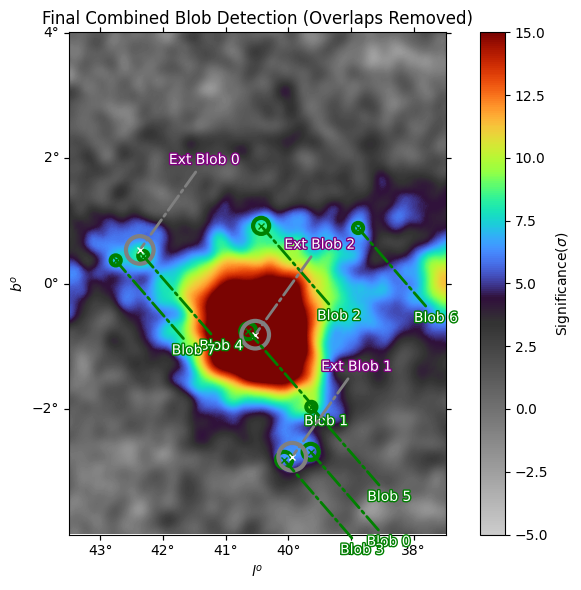

In [43]:
if len(all_ps_blobs) > 0:
    combined_ps_blobs = np.vstack(all_ps_blobs)
    # Flatten the list of lists of SkyCoord objects
    combined_pscoord_blobs = [coord for sublist in all_pscoord_blobs for coord in sublist]
    # Flatten the list of lists of radii values
    combined_psradius_blobs = [radius for sublist in all_psradius_blobs for radius in sublist]
else:
    combined_ps_blobs = np.array([]).reshape(0, 3)
    combined_pscoord_blobs = []
    combined_psradius_blobs = []

if len(all_ext_blobs) > 0:
    combined_ext_blobs = np.vstack(all_ext_blobs)
    # Flatten the list of lists of SkyCoord objects
    combined_extcoord_blobs = [coord for sublist in all_extcoord_blobs for coord in sublist]
    # Flatten the list of lists of radii values
    combined_extradius_blobs = [radius for sublist in all_extradius_blobs for radius in sublist]
else:
    combined_ext_blobs = np.array([]).reshape(0, 3)
    combined_extcoord_blobs = []
    combined_extradius_blobs = []

def remove_overlapping_blobs(blobs, coords, radii, overlap_threshold=0.5):
    """
    Remove overlapping blobs, keeping the one with larger radius.
    
    Parameters:
    -----------
    blobs : array of shape (n_blobs, 3)
        Each row: [y, x, radius]
    coords : list of SkyCoord objects
        Corresponding sky coordinates
    radii : list of float
        Corresponding radii values
    overlap_threshold : float
        Fraction of overlap to consider blobs as duplicates
    """
    if len(blobs) == 0:
        return blobs, coords, radii
    
    # Sort by radius (descending) to keep larger blobs
    sorted_indices = np.argsort(blobs[:, 2])[::-1]
    sorted_blobs = blobs[sorted_indices]
    sorted_coords = [coords[i] for i in sorted_indices]  # Reorder list
    sorted_radii = [radii[i] for i in sorted_indices]  # Reorder list
    
    keep_mask = np.ones(len(sorted_blobs), dtype=bool)
    
    for i in range(len(sorted_blobs)):
        if not keep_mask[i]:
            continue
        
        # Calculate distance to all other blobs
        distances = np.sqrt((sorted_blobs[i, 0] - sorted_blobs[:, 0])**2 + 
                           (sorted_blobs[i, 1] - sorted_blobs[:, 1])**2)
        
        # Check for overlap
        radii_sum = sorted_blobs[i, 2] + sorted_blobs[:, 2]
        overlap = (radii_sum - distances) / np.minimum(sorted_blobs[i, 2], sorted_blobs[:, 2])
        
        # Mark overlapping blobs (except itself) for removal
        keep_mask[overlap > overlap_threshold] = False
        keep_mask[i] = True  # Keep the current blob
    
    # Filter all arrays/lists by keep_mask
    filtered_blobs = sorted_blobs[keep_mask]
    filtered_coords = [coord for i, coord in enumerate(sorted_coords) if keep_mask[i]]
    filtered_radii = [radius for i, radius in enumerate(sorted_radii) if keep_mask[i]]
    
    return filtered_blobs, filtered_coords, filtered_radii

# Remove overlaps
final_ps_blobs, final_pscoords_blobs, final_psradius_blobs = remove_overlapping_blobs(
    combined_ps_blobs, combined_pscoord_blobs, combined_psradius_blobs)
final_ext_blobs, final_extcoords_blobs, final_extradius_blobs = remove_overlapping_blobs(
    combined_ext_blobs, combined_extcoord_blobs, combined_extradius_blobs)

print(f"Combined point sources: {len(combined_ps_blobs)} → After removing overlaps: {len(final_ps_blobs)}")
print(f"Combined extended sources: {len(combined_ext_blobs)} → After removing overlaps: {len(final_ext_blobs)}")

# Plot final results (only if there are blobs to plot)
if len(final_ps_blobs) > 0 or len(final_ext_blobs) > 0:
    blobs_dict = {
        'psblobs': final_ps_blobs,
        'extblobs': final_ext_blobs,
    }
    fig, ax = make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, 
                         title='Final Combined Blob Detection (Overlaps Removed)', cmap='ult', labels=['4haawc'])
    if save_pdf:
        pdf.savefig(fig)
else:
    print("No blobs found to plot")

After removing PS-EXT overlaps:
  Point sources: 5
  Extended sources: 3


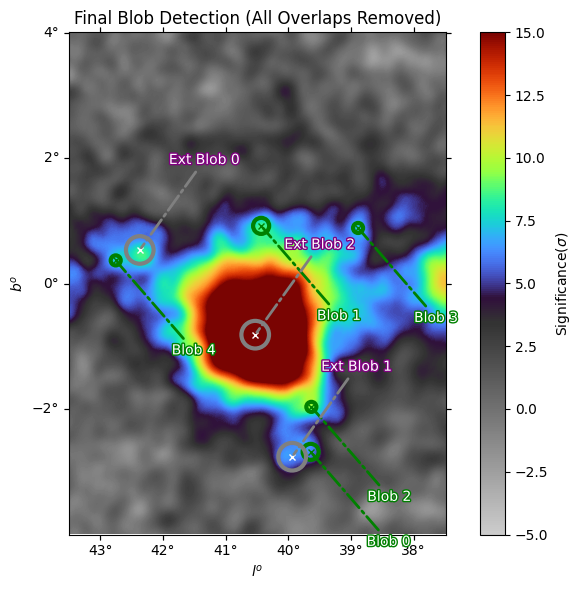

In [44]:

def remove_cross_overlap(ps_blobs, ps_coords, ps_radii, ext_blobs, ext_coords, ext_radii, overlap_threshold=0.5):
    """
    Remove overlaps between point source and extended source blobs.
    Priority: Keep extended sources, remove overlapping point sources.
    
    Parameters:
    -----------
    ps_blobs : array of shape (n_blobs, 3)
        Point source blobs [y, x, radius]
    ps_coords : list of SkyCoord objects
        Point source sky coordinates
    ps_radii : list of float
        Point source radii values
    ext_blobs : array of shape (n_blobs, 3)
        Extended source blobs [y, x, radius]
    ext_coords : list of SkyCoord objects
        Extended source sky coordinates
    ext_radii : list of float
        Extended source radii values
    overlap_threshold : float
        Fraction of overlap to consider blobs as duplicates
    
    Returns:
    --------
    filtered_ps_blobs : array
        Point source blobs with overlaps removed
    filtered_ps_coords : list
        Point source coords with overlaps removed
    filtered_ps_radii : list
        Point source radii with overlaps removed
    ext_blobs : array
        Extended source blobs (unchanged)
    ext_coords : list
        Extended source coords (unchanged)
    ext_radii : list
        Extended source radii (unchanged)
    """
    if len(ps_blobs) == 0 or len(ext_blobs) == 0:
        return ps_blobs, ps_coords, ps_radii, ext_blobs, ext_coords, ext_radii
    
    keep_mask = np.ones(len(ps_blobs), dtype=bool)
    
    for i in range(len(ps_blobs)):
        # Calculate distance to all extended source blobs
        distances = np.sqrt((ps_blobs[i, 0] - ext_blobs[:, 0])**2 + 
                           (ps_blobs[i, 1] - ext_blobs[:, 1])**2)
        
        # Check for overlap with any extended source
        radii_sum = ps_blobs[i, 2] + ext_blobs[:, 2]
        overlap = (radii_sum - distances) / np.minimum(ps_blobs[i, 2], ext_blobs[:, 2])
        
        # If this point source overlaps with any extended source, remove it
        if np.any(overlap > overlap_threshold):
            keep_mask[i] = False
    
    # Filter point source arrays/lists by keep_mask
    filtered_ps_blobs = ps_blobs[keep_mask]
    filtered_ps_coords = [coord for i, coord in enumerate(ps_coords) if keep_mask[i]]
    filtered_ps_radii = [radius for i, radius in enumerate(ps_radii) if keep_mask[i]]
    
    return filtered_ps_blobs, filtered_ps_coords, filtered_ps_radii, ext_blobs, ext_coords, ext_radii

# Remove overlaps between point sources and extended sources
final_ps_blobs, final_pscoords_blobs, final_psradius_blobs, final_ext_blobs, final_extcoords_blobs, final_extradius_blobs = remove_cross_overlap(
    final_ps_blobs, final_pscoords_blobs, final_psradius_blobs,
    final_ext_blobs, final_extcoords_blobs, final_extradius_blobs)

print(f"After removing PS-EXT overlaps:")
print(f"  Point sources: {len(final_ps_blobs)}")
print(f"  Extended sources: {len(final_ext_blobs)}")

# Plot final results
if len(final_ps_blobs) > 0 or len(final_ext_blobs) > 0:
    blobs_dict = {
        'psblobs': final_ps_blobs,
        'extblobs': final_ext_blobs,
    }
    fig, ax = make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, 
                         title='Final Blob Detection (All Overlaps Removed)', cmap='ult', labels=['4hawac'])
    if save_pdf:
        pdf.savefig(fig)
else:
    print("No blobs found to plot")

In [45]:
def convert_sources(coords, radii, radius_to_sigma, name_prefix="Drip", source_type=None):
    """
    Convert blob coordinates and radii to a DataFrame.
    
    Parameters:
    -----------
    coords : list of SkyCoord objects
        Sky coordinates
    radii : list of float
        Radii values
    radius_to_sigma : function
        Function to convert radius to sigma
    name_prefix : str
        Prefix for source names
    source_type : str, optional
        Type of source ('PS' for point source, 'EXT' for extended source)
    
    Returns:
    --------
    df : pandas.DataFrame
        DataFrame with source information
    """
    df = pd.DataFrame({
        'Names': [f'{name_prefix}{i}' for i in range(len(coords))],
        'ra': [c.ra.deg for c in coords],
        'dec': [c.dec.deg for c in coords],
        'Circle Radius': radii,
    })
    df['Sigma Radius'] = [radius_to_sigma(r) for r in radii]
    
    if source_type is not None:
        df['Type'] = source_type
    
    return df

# print(f"  Point sources: {len(final_pscoords_blobs)}")
# print(f"  Extended sources: {len(final_extcoords_blobs)}")
# Convert point sources
ps_df = convert_sources(final_pscoords_blobs, final_psradius_blobs, 
                        radius_to_sigma, name_prefix="DripPS", source_type="PS")

# Convert extended sources
ext_df = convert_sources(final_extcoords_blobs, final_extradius_blobs, 
                         radius_to_sigma, name_prefix="DripEXT", source_type="EXT")

# Combine into single DataFrame
filtered_df = pd.concat([ps_df, ext_df], ignore_index=True)

print(f"\nFinal DataFrame:")
print(f"  Total sources: {len(filtered_df)}")
print(f"  Point sources: {len(ps_df)}")
print(f"  Extended sources: {len(ext_df)}")
print("\nDataFrame preview:")
print(filtered_df.head(10))


Final DataFrame:
  Total sources: 8
  Point sources: 5
  Extended sources: 3

DataFrame preview:
      Names          ra       dec  Circle Radius  Sigma Radius Type
0   DripPS0  288.319037  4.737991          0.128      0.084478   PS
1   DripPS1  285.469934  7.094862          0.128      0.084478   PS
2   DripPS2  287.675800  5.059234          0.080      0.052798   PS
3   DripPS3  284.789336  5.706027          0.080      0.052798   PS
4   DripPS4  287.037129  8.900622          0.080      0.052798   PS
5  DripEXT0  286.708933  8.637002          0.220      0.145196  EXT
6  DripEXT1  288.524804  4.963039          0.220      0.145196  EXT
7  DripEXT2  287.064259  6.383111          0.220      0.145196  EXT


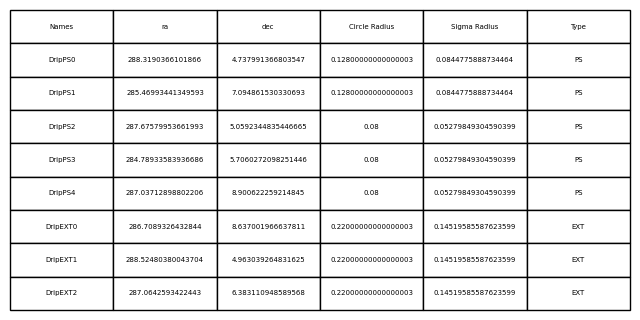

In [46]:
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off') 

try:
    table = ax.table(cellText=filtered_df.values,
                        colLabels=filtered_df.columns,
                        cellLoc='center',
                        loc='center')

    table.scale(1, 2)
except:
    text = f"DRIPS Compilation of Result for Crab Simulation Run {file}. No Source Found"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
plt.show()
plt.close(fig)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
23.040000000000006
23.040000000000006
14.4
14.4
14.4
39.6
39.6
39.6


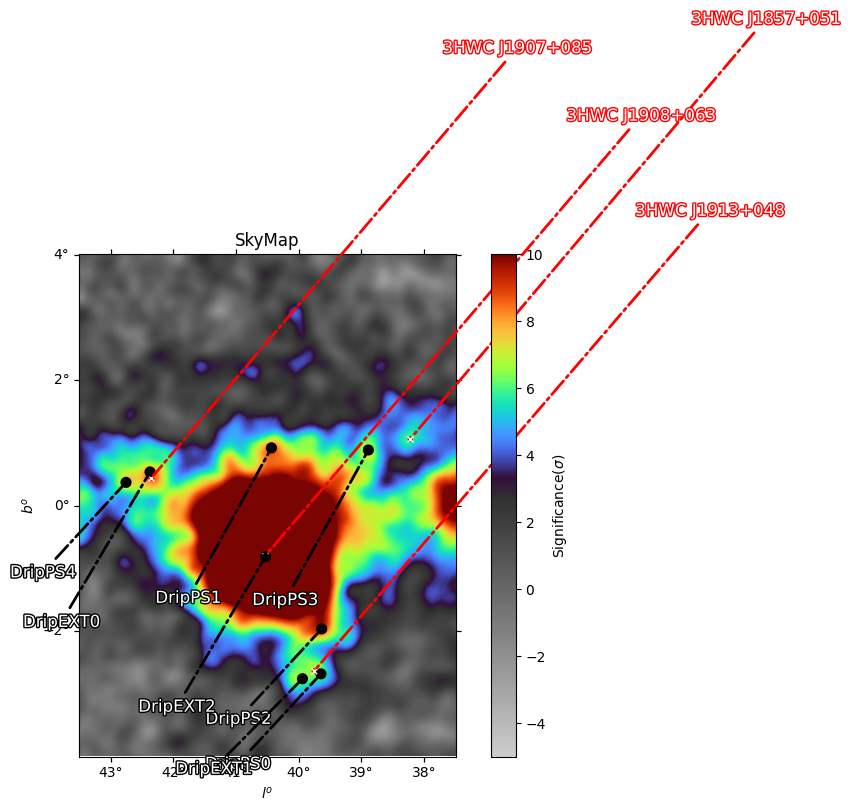

In [47]:
# Plot the Final Seeds
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
seed_final = pd.DataFrame({
    "Name": filtered_df['Names'], 
    "ra": filtered_df['ra'],
    "dec":  filtered_df['dec'], 
    # "ext": filtered_df['Sigma Radius'],
    "ext": filtered_df['Circle Radius'],
    })
name = ['ic443 ps', 'halo ext']
ra = [94.42, 93.67]
dec = [22.35, 22.22]
ext = [0.01, 1.05]
hotspots2 = pd.DataFrame({
    "Name": name, 
    "ra": ra,
    "dec":  dec, 
    "ext": ext,
    })

fig,ax=make_plots(array, wcs, pixel_size,threshold=3, vmin=-5, vmax=10,  coordsys='G',hotspots=sources3hwc, hotspots2=None, title=f'SkyMap', cmap='ult', labels=['4haawc', '1lhaaaso', '4fagl', 'sanr', 'pulsaar'])

for i in range(len(seed_final)):
    coord2 = SkyCoord(ra=filtered_df['ra'][i]*u.deg, dec=filtered_df['dec'][i]*u.deg)
    pixelcoord = astropy_utils.skycoord_to_pixel(coord2, wcs)
    r = filtered_df['Circle Radius'][i] / pixel_size
    print(r)
    if i%2 == 0:
        if r > 50:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='purple')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(-50, -90), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='purple', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="purple")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), r, color='purple', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='black')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(-50, -90), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='black', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="black")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='black', linewidth=3, fill=False)
    else:
        if r > 50:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='purple')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(-50, -150), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='purple', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="purple")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), r, color='purple', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='black')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(-50, -150), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='black', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="black")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='black', linewidth=3, fill=False)
    ax.add_patch(c)

for i in range(len(hotspots2)):
    coord2 = SkyCoord(ra=ra[i]*u.deg, dec=dec[i]*u.deg)
    pixelcoord = astropy_utils.skycoord_to_pixel(coord2, wcs)
    r = 2*ext[i] / pixel_size
    # print(r)
    if i%2 == 0:
        if r > 100:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 90), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), r, color='green', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 150), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='green', linewidth=3, fill=False)
    else:
        if r > 100:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 120), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), r, color='green', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 160), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='green', linewidth=3, fill=False)
    ax.add_patch(c)


if save_pdf:
    pdf.savefig(fig)
    pdf.close()